In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu
app = pd.read_csv("Application_Data.csv")
pkt = pd.read_csv("Packet_Network_Data.csv")

# Tiền xử lý
app["timestamp"] = pd.to_datetime(app["timestamp"], errors="coerce")
pkt["frame.time_epoch"] = pd.to_numeric(pkt["frame.time_epoch"], errors="coerce")
pkt["frame.len"] = pd.to_numeric(pkt["frame.len"], errors="coerce")
pkt["tcp.len"] = pd.to_numeric(pkt["tcp.len"], errors="coerce")

app = app.sort_values("timestamp")

Biểu đồ 1. Failed Login theo địa chỉ IP

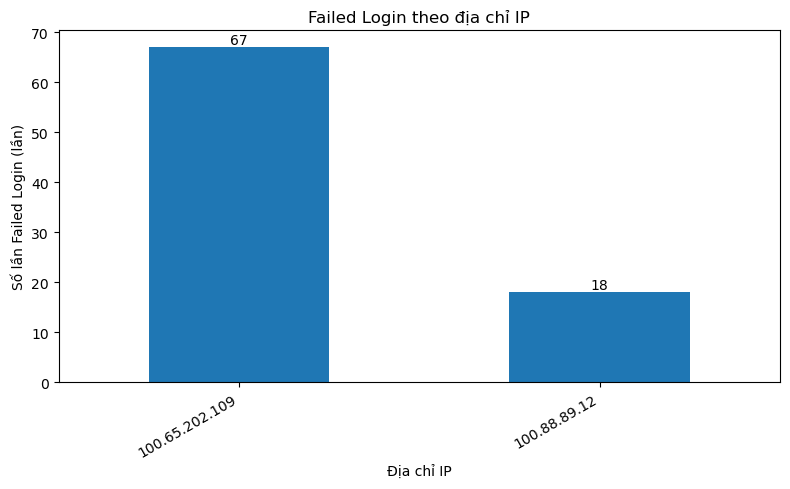

In [2]:
failed_by_ip = app[app["login_status"] == "Failed"]["ip_address"].value_counts()

plt.figure(figsize=(8, 5))
ax = failed_by_ip.plot(kind="bar")
plt.title("Failed Login theo địa chỉ IP")
plt.xlabel("Địa chỉ IP")
plt.ylabel("Số lần Failed Login (lần)")
plt.xticks(rotation=30, ha="right")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

Biểu đồ 2. Top Username

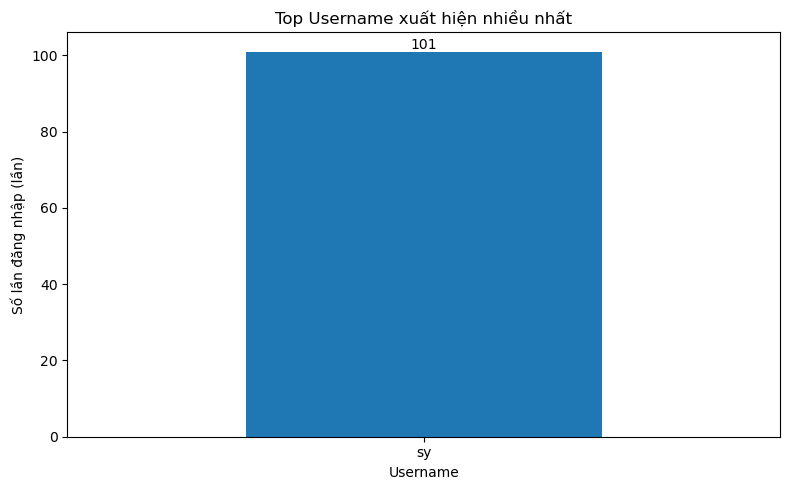

In [4]:
top_user = app["username"].value_counts().head(10)

plt.figure(figsize=(8, 5))
ax = top_user.plot(kind="bar")
plt.title("Top Username xuất hiện nhiều nhất")
plt.xlabel("Username")
plt.ylabel("Số lần đăng nhập (lần)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

Biểu đồ 3. Login Frequency theo thời gian

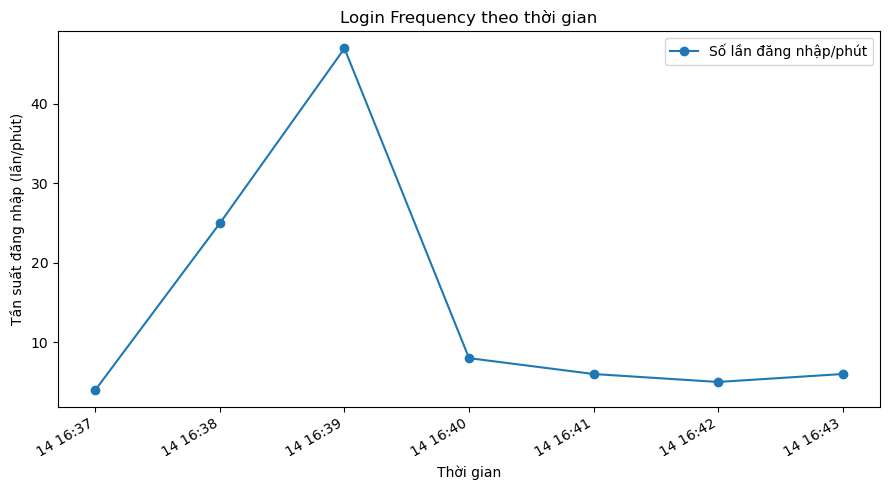

In [5]:
login_time = app.set_index("timestamp").resample("1min").size()

plt.figure(figsize=(9, 5))
plt.plot(login_time.index, login_time.values, marker="o", label="Số lần đăng nhập/phút")
plt.title("Login Frequency theo thời gian")
plt.xlabel("Thời gian")
plt.ylabel("Tần suất đăng nhập (lần/phút)")
plt.legend()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Biểu đồ 4. Failed Login và Success Login

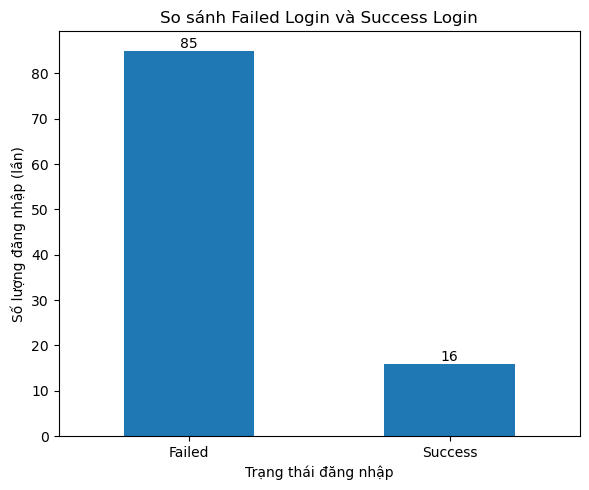

In [6]:
status_count = app["login_status"].value_counts()

plt.figure(figsize=(6, 5))
ax = status_count.plot(kind="bar")
plt.title("So sánh Failed Login và Success Login")
plt.xlabel("Trạng thái đăng nhập")
plt.ylabel("Số lượng đăng nhập (lần)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

Biểu đồ 5. Delay của phiên SSH

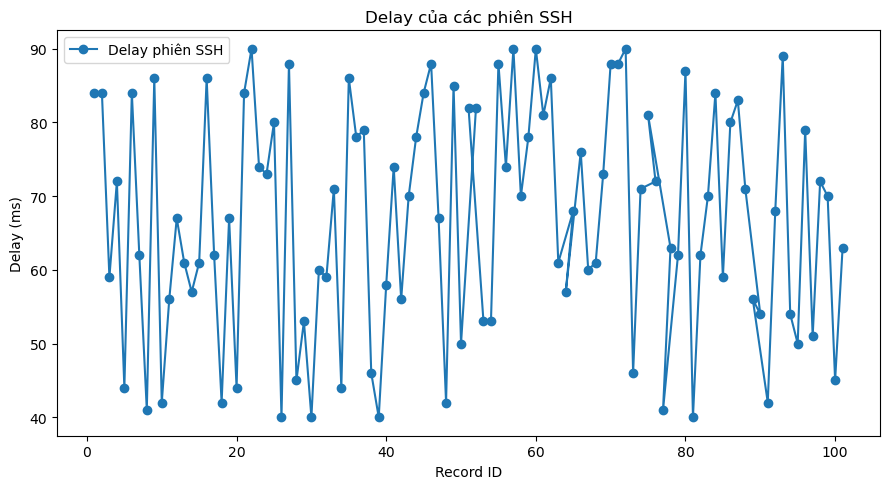

In [7]:
plt.figure(figsize=(9, 5))
plt.plot(app["record_id"], app["delay_ms"], marker="o", label="Delay phiên SSH")
plt.title("Delay của các phiên SSH")
plt.xlabel("Record ID")
plt.ylabel("Delay (ms)")
plt.legend()
plt.tight_layout()
plt.show()